# Super Store — OOP Analysis Notebook


#  Dataset Overview

## What is this dataset?

This is a **retail sales dataset** from a global superstore chain,
structured as a classic **star schema**: one central fact table
(`FactSales`) surrounded by dimension tables (Product, Customer,
Geography, ShipMode, OrderPriority, Date), which are merged into a
single flat table for analysis.

**Grain (row level):** each row represents **one line item within one
order** — i.e., one specific product sold as part of a specific
order. If a customer buys 3 different products in a single order,
that's 3 rows, not 1. This matters: to count *orders*, use
`Order ID.nunique()`, not the row count.

**Size & scope:**
- **49,670 rows** × **39 columns** (before feature engineering)
- **795 unique customers**
- Covers order dates from **2011 to 2014**
- Sales span multiple global markets (US, LATAM, EU, APAC, EMEA,
  Africa, Canada)

**No missing values** and **no duplicate records** — the dataset was
fully cleaned (including a fix for a data-entry bug in `IsReturned`)
before this analysis.

## Column Reference

| Column | Type | Description |
|---|---|---|
| `SalesKey` | Key | Unique technical ID for each row (post-merge artifact) |
| `Order ID` | Key | ID of the order; shared across all line items in the same order |
| `Product ID` | Key | ID of the product sold |
| `CustomerID` | Key | ID of the customer who placed the order |
| `Sales` | Measure | Revenue generated by this line item |
| `Quantity` | Measure | Number of units sold in this line item |
| `Discount` | Measure | Discount rate applied (0 to 0.85, i.e. 0%–85%) |
| `Profit` | Measure | Net profit for this line item (can be negative) |
| `Shipping Cost` | Measure | Cost to ship this line item |
| `IsReturned` | Flag | Whether this item was returned (`Yes`/`No`) |
| `ProductName` | Product | Full product name |
| `Category` | Product | Top-level product category (Furniture, Office Supplies, Technology) |
| `Sub-Category` | Product | More specific product grouping within a Category |
| `CustomerName` | Customer | Name of the customer |
| `Segment` | Customer | Customer type: Consumer, Corporate, or Home Office |
| `City` | Geography | City of the order's delivery address |
| `State` | Geography | State/province of the delivery address |
| `Country` | Geography | Country of the delivery address |
| `Region` | Geography | Broader geographic region (e.g. West, EMEA, Southeast Asia) |
| `Market` | Geography | Highest-level market grouping (US, LATAM, EU, APAC, EMEA, Africa, Canada) |
| `ShipMode` | Shipping | Shipping method (Standard/Second/First Class, Same Day) |
| `OrderPriority` | Shipping | Order urgency level (Low, Medium, High, Critical) |
| `OrderDate` | Time | Date the order was placed |
| `ShipDate` | Time | Date the order was shipped |
| `Order_GregorianYearInt` | Time | Calendar year of the order date |
| `Order_GregorianMonthNo` | Time | Calendar month number (1–12) of the order date |
| `Order_GregorianMonthName` | Time | Calendar month name of the order date |
| `Order_GregorianDayOfWeekName` | Time | Day of week name of the order date |
| `Order_SeasonName` | Time | Season of the order date (Spring/Summer/Fall/Winter) |
| `Order_IsGregorianLeap` | Time | Whether the order year is a leap year |
| `Ship_GregorianYearInt` | Time | Calendar year of the ship date |
| `Ship_GregorianMonthNo` | Time | Calendar month number of the ship date |
| `Ship_GregorianMonthName` | Time | Calendar month name of the ship date |
| `Ship_GregorianDayOfWeekName` | Time | Day of week name of the ship date |
| `Ship_SeasonName` | Time | Season of the ship date |
| `Ship_IsGregorianLeap` | Time | Whether the ship year is a leap year |
| `GeoKey`, `ShipModeID`, `PriorityKey` | Key | Internal join keys (from the original star schema merge) |

> **Note:** a few additional engineered columns (`shipping_duration`,
> `profit_margin`, `discount_tier`, etc.) are created later in the
> **Feature Engineering** section — see that section for their
> definitions.

## 1. Build the dataset (loading + merging)

In [1]:
from Statistics import SalesDataBuilder, SalesDataCleaner, EDAVisualizer, HypothesisTester, InteractiveEDA

In [2]:
builder = SalesDataBuilder(base_path="/Users/faridradin/super-store/Data")
raw_df = builder.build()

--- date ---
(47483, 47)
0 null values

--- product ---
(10246, 4)
0 null values

--- customer ---
(1589, 3)
0 null values

--- geography ---
(3772, 6)
0 null values

--- shipMode ---
(4, 2)
0 null values

--- orderPriority ---
(4, 2)
0 null values

--- factSales ---
(49670, 15)
0 null values

FactSales dtypes:
 Product ID     object
CustomerID     object
GeoKey          int64
ShipModeID      int64
PriorityKey     int64
dtype: object

Product ProductID dtype: object
Customer CustomerID dtype: object
Geography GeoKey dtype: int64
ShipMode ShipModeID dtype: int64
OrderPriority PriorityKey dtype: int64
Initial number of rows: 49670
After Product: 49670
After Customer: 49670
After Geography: 49670
After ShipMode: 49670
After OrderPriority: 49670
After Order Date: 49670
After Ship Date: 49670
(49670, 42)
Series([], dtype: int64)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49670 entries, 0 to 49669
Data columns (total 39 columns):
 #   Column                        Non-Null Count  Dtyp

## 2. Clean the dataset

In [3]:
cleaner = SalesDataCleaner(raw_df)
df = cleaner.clean()

Duplicate rows: 0
SalesKey: 0
Rows with invalid dates: 0
Invalid Quantity: 0
Invalid Sales: 0
Invalid Discount: 0
Series([], dtype: int64)
--- Segment ---
Segment
Consumer       25724
Corporate      14927
Home Office     9019
Name: count, dtype: int64

--- Category ---
Category
Office Supplies    30287
Technology          9788
Furniture           9595
Name: count, dtype: int64

--- Sub-Category ---
Sub-Category
Binders        5967
Storage        4849
Art            4680
Paper          3479
Chairs         3340
Phones         3244
Furnishings    3088
Accessories    3011
Labels         2550
Envelopes      2374
Fasteners      2364
Supplies       2349
Bookcases      2319
Copiers        2133
Appliances     1675
Machines       1400
Tables          848
Name: count, dtype: int64

--- Region ---
Region
Central           10249
South              6490
EMEA               4835
North              4568
Africa             4453
Oceania            3487
West               3187
Southeast Asia     3129
East

Number of unique customers: 795
        frequency      monetary  recency_days  total_profit
count  795.000000    795.000000    795.000000    795.000000
mean    31.488050  15234.654648     24.435220   1773.891514
std      5.301803   5095.061452     28.310206   1492.660701
min     14.000000   3877.406975      0.000000  -6151.559782
25%     28.000000  11516.557998      6.000000    934.860433
50%     31.000000  14487.165863     18.000000   1706.232432
75%     35.000000  18239.941525     33.000000   2513.024387
max     46.000000  38753.077493    428.000000   8532.894364
Average feature values per segment:
         recency_days  frequency      monetary  total_profit
segment                                                     
0           18.651899  37.126582  22578.552889   2980.011443
1           22.552347  26.617329  11511.641025   1302.259114
2           17.261981  33.412141  15027.411677   1610.310046
3          102.744681  28.425532  13868.822766   1588.279290


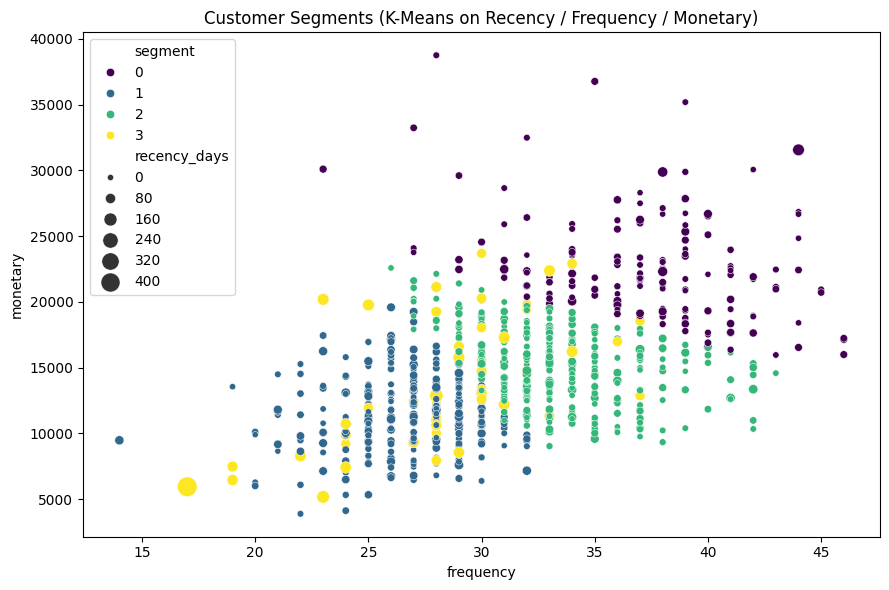

In [4]:
from Statistics import CustomerAnalyzer

analyzer = CustomerAnalyzer(df)
rfm = analyzer.build_rfm_table()
rfm = analyzer.cluster_customers(n_clusters=4)
analyzer.plot_rfm_segments()

In [5]:
cleaner.save_to_csv("/Users/faridradin/super-store/Data/sales_dataset_statistics.csv")

shape : (49670, 39)


# EDA

In [6]:
eda = EDAVisualizer(df)

In [7]:
eda.show_head()

,Order ID,Product ID,Sales,Quantity,Discount,Profit,Shipping Cost,CustomerID,OrderDate,IsReturned,...,Order_GregorianMonthName,Order_GregorianDayOfWeekName,Order_SeasonName,Order_IsGregorianLeap,Ship_GregorianYearInt,Ship_GregorianMonthNo,Ship_GregorianMonthName,Ship_GregorianDayOfWeekName,Ship_SeasonName,Ship_IsGregorianLeap
0,CA-2014-146780,FUR-FU-10001934,41.959999,2,0.0,10.9096,4.18,CV-12805,2014-12-26,No,...,December,Friday,Winter,0,2014,12,December,Wednesday,Winter,0
1,CA-2013-138520,OFF-EN-10001137,8.260000,2,0.0,3.7996,0.69,JL-15505,2013-04-09,No,...,April,Tuesday,Spring,0,2013,4,April,Sunday,Spring,0
2,CA-2014-144904,OFF-LA-10001158,20.700001,2,0.0,9.9360,0.74,KW-16435,2014-09-26,No,...,September,Friday,Fall,0,2014,10,October,Thursday,Fall,0
3,CA-2014-144904,OFF-AR-10003732,5.560000,2,0.0,1.4456,0.42,KW-16435,2014-09-26,No,...,September,Friday,Fall,0,2014,10,October,Thursday,Fall,0
4,CA-2013-123274,FUR-FU-10004090,44.459999,2,0.0,14.6718,3.97,GT-14710,2013-02-19,No,...,February,Tuesday,Winter,0,2013,2,February,Sunday,Winter,0


In [ ]:
eda.describe_numeric()     

,count,mean,min,25%,50%,75%,max,std
Sales,49670.0,243.840355,0.444,30.384001,83.970001,247.829998,22638.5,485.963091
Quantity,49670.0,3.470787,1.0,2.0,3.0,5.0,14.0,2.274854
Discount,49670.0,0.14307,0.0,0.0,0.0,0.2,0.85,0.212046
Profit,49670.0,28.392264,-6599.97998,0.0,9.154,36.2664,8399.980469,172.39952
Shipping Cost,49670.0,26.041125,0.002,2.58,7.66,23.968999,933.570007,56.870281
OrderDate,49670,2013-05-08 10:27:27.578014720,2011-01-01 00:00:00,2012-06-15 00:00:00,2013-07-02 00:00:00,2014-05-19 00:00:00,2014-12-31 00:00:00,NaN
SalesKey,49670.0,24835.5,1.0,12418.25,24835.5,37252.75,49670.0,14338.638272
ShipDate,49670,2013-05-12 09:47:18.397423104,2011-01-03 00:00:00,2012-06-19 00:00:00,2013-07-05 00:00:00,2014-05-23 00:00:00,2015-01-07 00:00:00,NaN
PriorityKey,49670.0,1.594947,1.0,1.0,1.0,2.0,4.0,0.82074
GeoKey,49670.0,937.66811,1.0,178.0,656.0,1468.0,3772.0,908.479336


In [ ]:
eda.describe_categorical()  

,count,unique,top,freq
Order ID,49670,25033,CA-2014-100111,14
Product ID,49670,10246,OFF-AR-10003651,32
CustomerID,49670,1589,PO-18850,97
IsReturned,49670,2,No,46690
ProductName,49670,3662,Staples,221
Category,49670,3,Office Supplies,30287
Sub-Category,49670,17,Binders,5967
CustomerName,49670,795,Steven Ward,104
Segment,49670,3,Consumer,25724
City,49670,3590,New York City,911


# Feature Engineering

In [ ]:
cleaner.engineer_features()
df = cleaner.df  

New columns added: shipping_duration, shipping_cost_pct, profit_margin, discount_tier, is_loss
       shipping_duration  shipping_cost_pct  profit_margin
count       49670.000000       49670.000000   49670.000000
mean            3.972116           0.108987       0.048526
std             1.727310           0.069715       0.464591
min             0.000000           0.000033      -4.733558
25%             3.000000           0.063048       0.000000
50%             4.000000           0.090115       0.169474
75%             5.000000           0.136096       0.337072
max             7.000000           0.589637       0.500001

Mean Profit and order count by discount tier:
                    mean  count
discount_tier                  
0%             60.759734  28103
0-20%          64.734140   5586
20-40%         12.078469   6149
40%+          -74.569004   9832


In [11]:
from Statistics import CustomerAnalyzer

analyzer = CustomerAnalyzer(df)
rfm = analyzer.build_rfm_table()

Number of unique customers: 795
        frequency      monetary  recency_days  total_profit
count  795.000000    795.000000    795.000000    795.000000
mean    31.488050  15234.654648     24.435220   1773.891514
std      5.301803   5095.061452     28.310206   1492.660701
min     14.000000   3877.406975      0.000000  -6151.559782
25%     28.000000  11516.557998      6.000000    934.860433
50%     31.000000  14487.165863     18.000000   1706.232432
75%     35.000000  18239.941525     33.000000   2513.024387
max     46.000000  38753.077493    428.000000   8532.894364


Average feature values per segment:
         recency_days  frequency      monetary  total_profit
segment                                                     
0           18.651899  37.126582  22578.552889   2980.011443
1           22.552347  26.617329  11511.641025   1302.259114
2           17.261981  33.412141  15027.411677   1610.310046
3          102.744681  28.425532  13868.822766   1588.279290


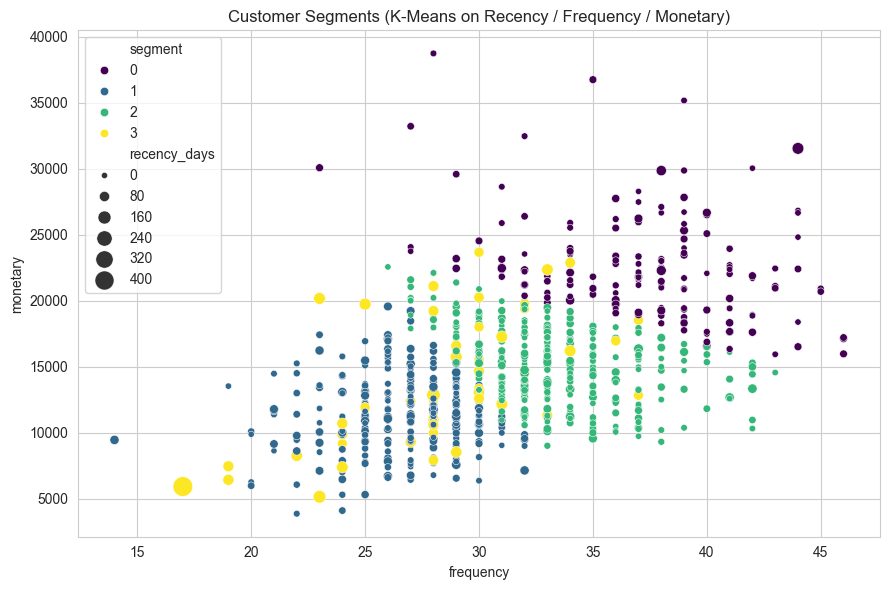

In [12]:
rfm = analyzer.cluster_customers(n_clusters=4)
analyzer.plot_rfm_segments()

### Univariate Analysis_Numerical Variable

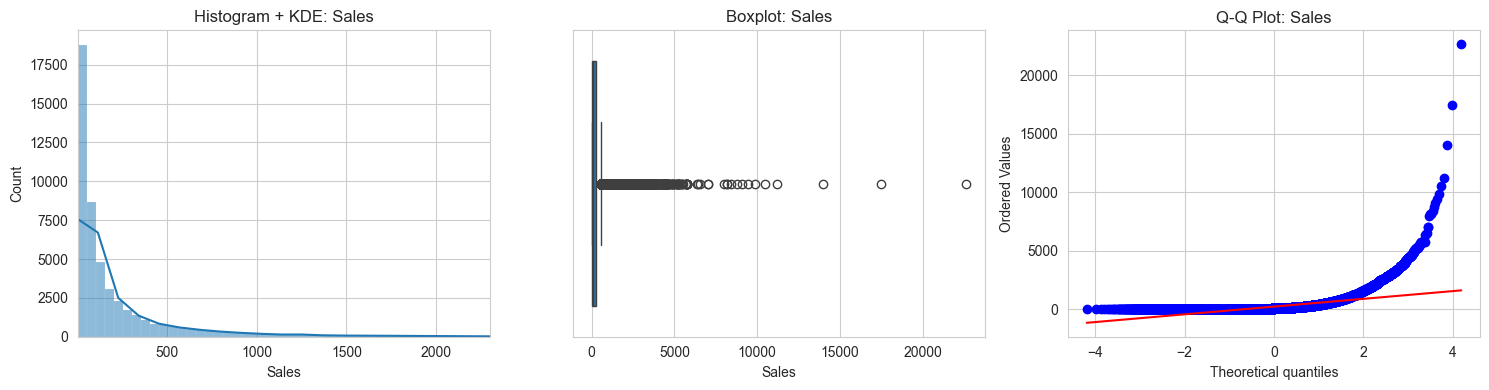

Sales: skewness=8.28, kurtosis=183.02


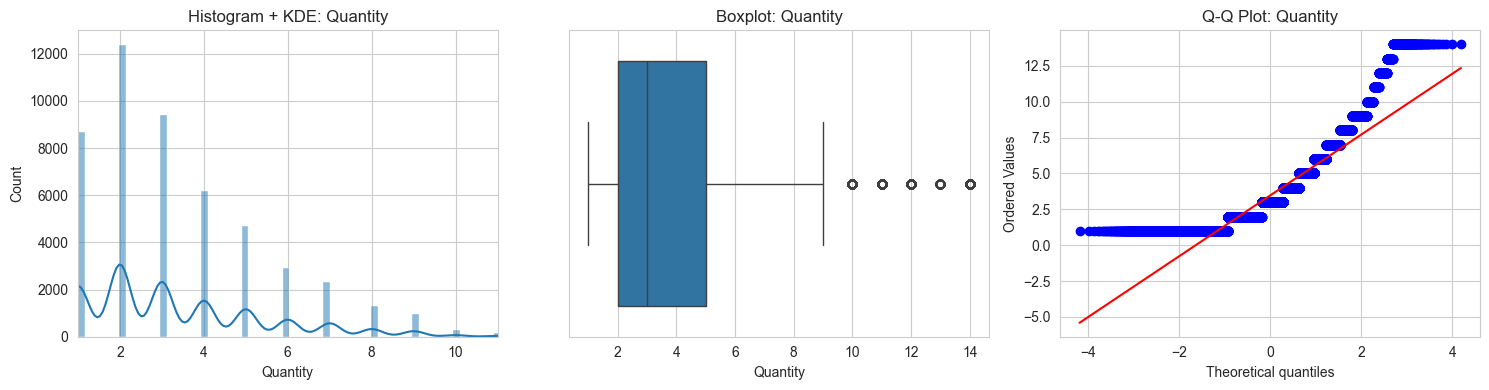

Quantity: skewness=1.36, kurtosis=2.28


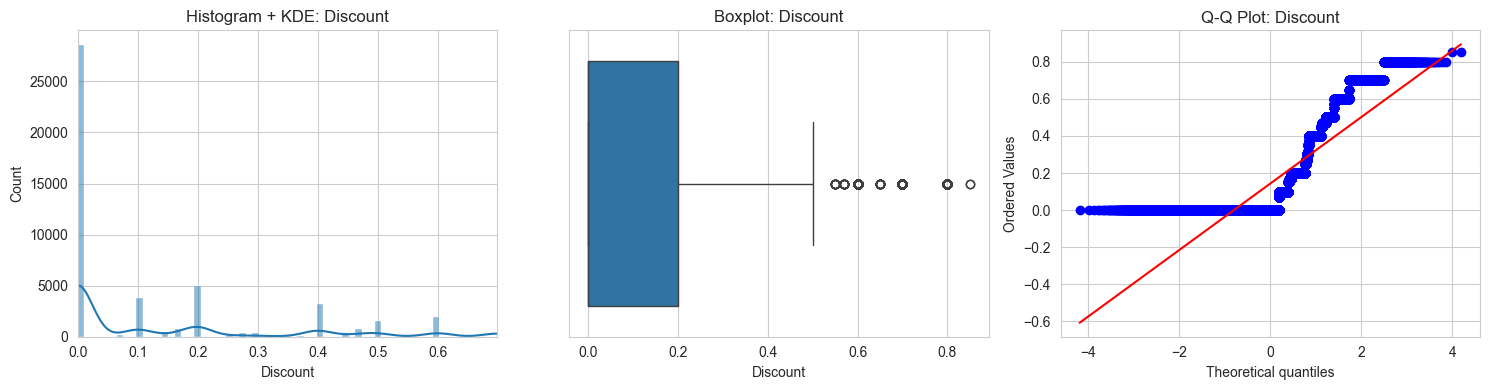

Discount: skewness=1.38, kurtosis=0.71


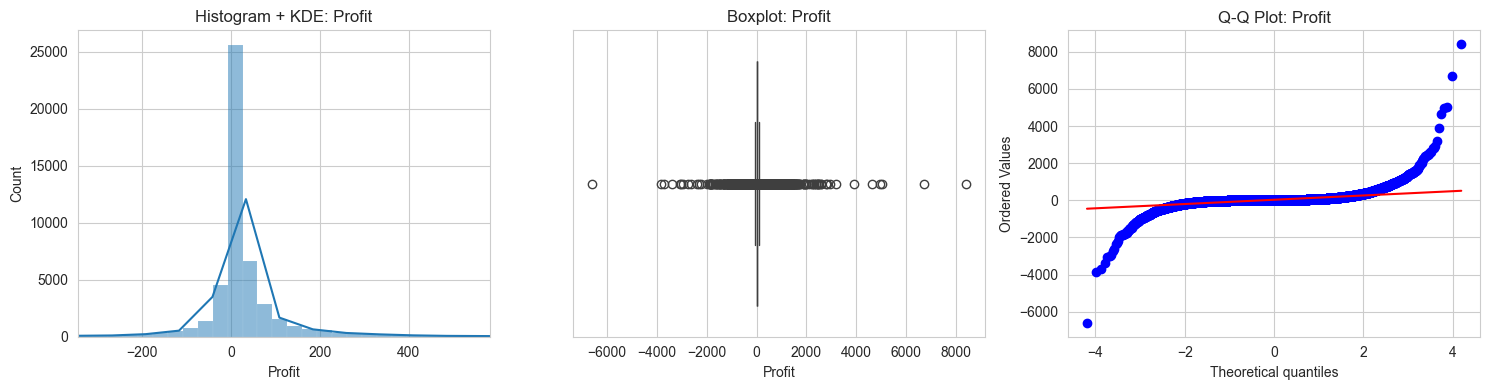

Profit: skewness=4.47, kurtosis=301.56


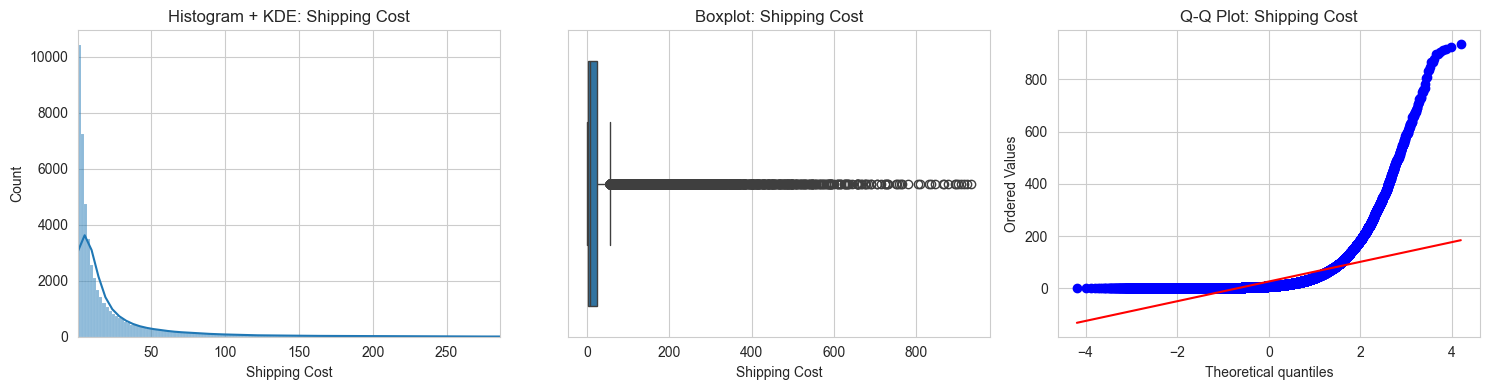

Shipping Cost: skewness=5.89, kurtosis=50.52


In [13]:
numeric_cols = ['Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Cost']
eda.plot_numeric_distributions(numeric_cols)

## Univariate Analysis_Categorical Variables

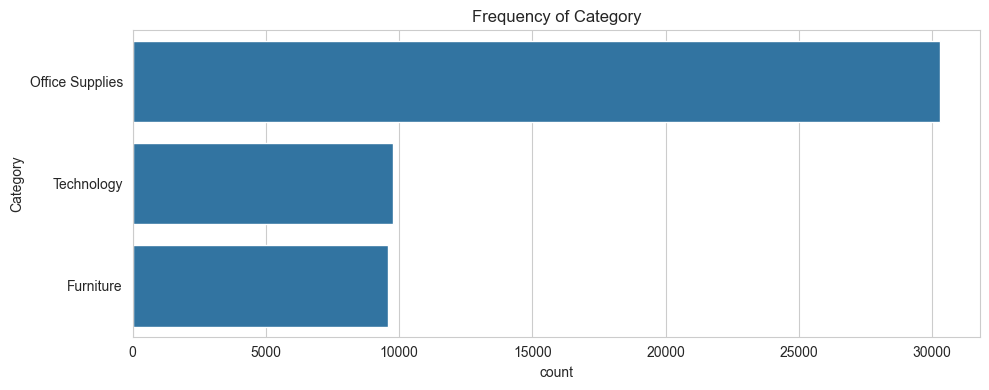

Category
Office Supplies    60.976445
Technology         19.706060
Furniture          19.317495
Name: proportion, dtype: float64


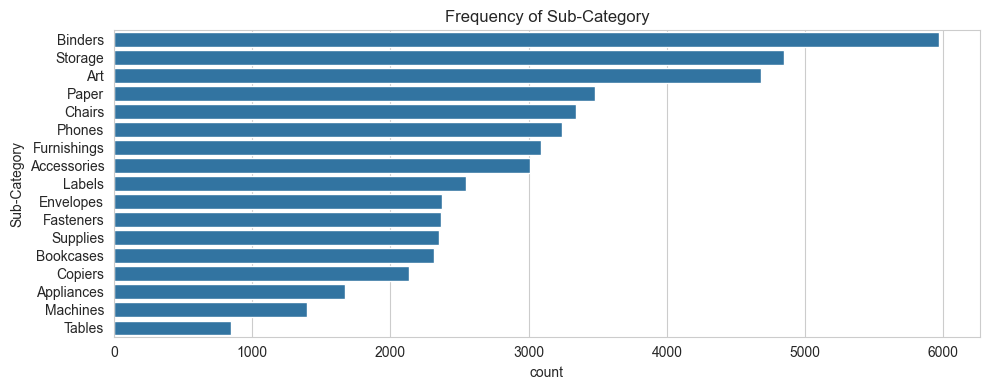

Sub-Category
Binders        12.013288
Storage         9.762432
Art             9.422186
Paper           7.004228
Chairs          6.724381
Phones          6.531105
Furnishings     6.217032
Accessories     6.062009
Labels          5.133884
Envelopes       4.779545
Fasteners       4.759412
Supplies        4.729213
Bookcases       4.668814
Copiers         4.294343
Appliances      3.372257
Machines        2.818603
Tables          1.707268
Name: proportion, dtype: float64


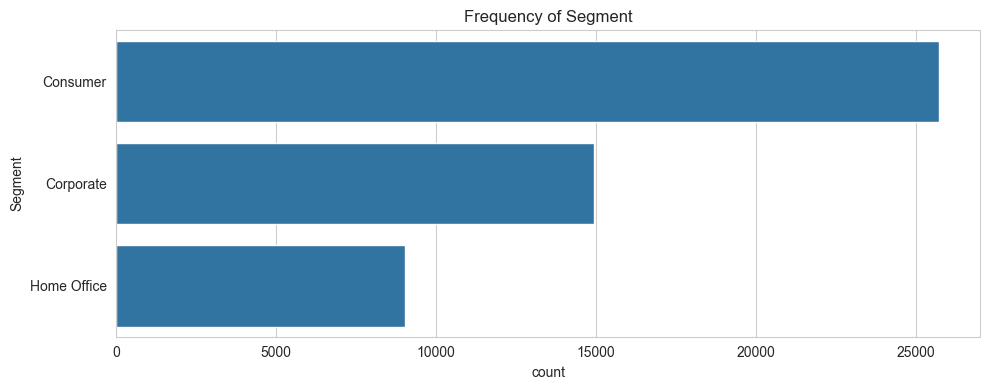

Segment
Consumer       51.789813
Corporate      30.052345
Home Office    18.157842
Name: proportion, dtype: float64


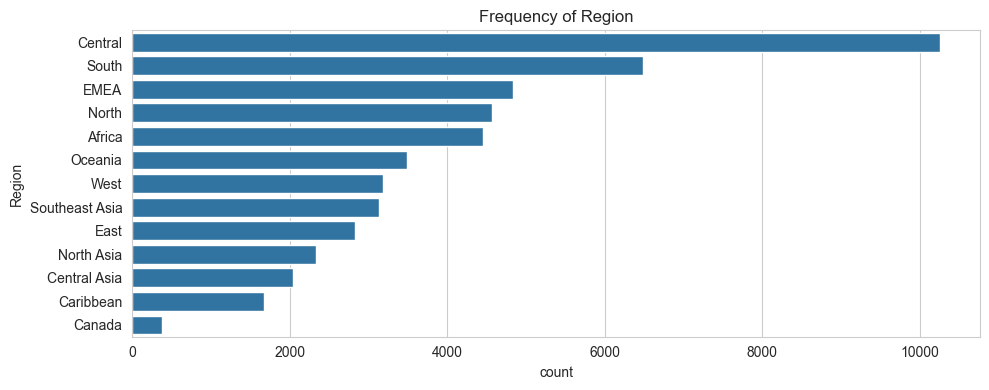

Region
Central           20.634186
South             13.066237
EMEA               9.734246
North              9.196698
Africa             8.965170
Oceania            7.020334
West               6.416348
Southeast Asia     6.299577
East               5.701631
North Asia         4.707067
Central Asia       4.123213
Caribbean          3.378297
Canada             0.756996
Name: proportion, dtype: float64


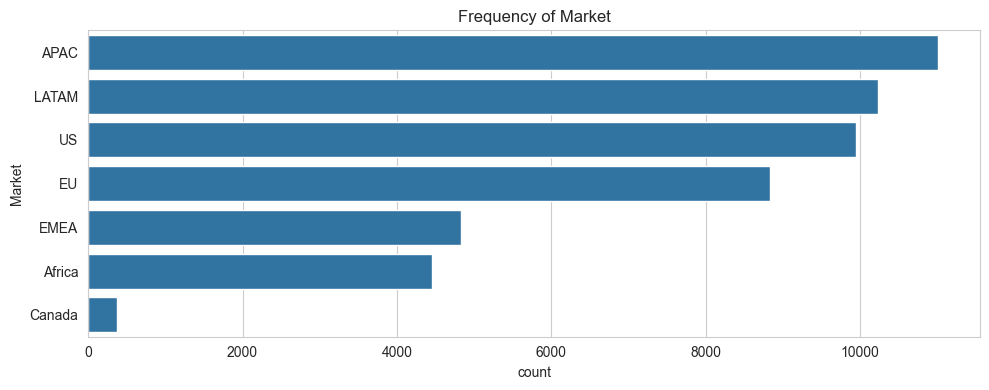

Market
APAC      22.150191
LATAM     20.593920
US        20.028186
EU        17.771291
EMEA       9.734246
Africa     8.965170
Canada     0.756996
Name: proportion, dtype: float64


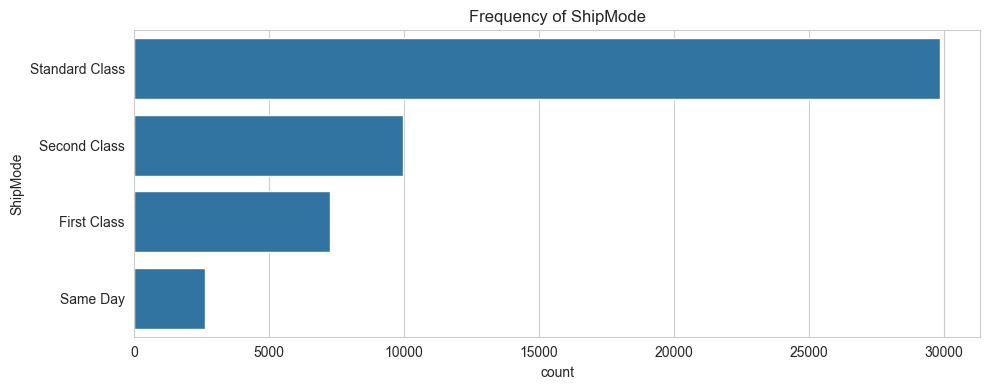

ShipMode
Standard Class    60.088585
Second Class      20.076505
First Class       14.560097
Same Day           5.274814
Name: proportion, dtype: float64


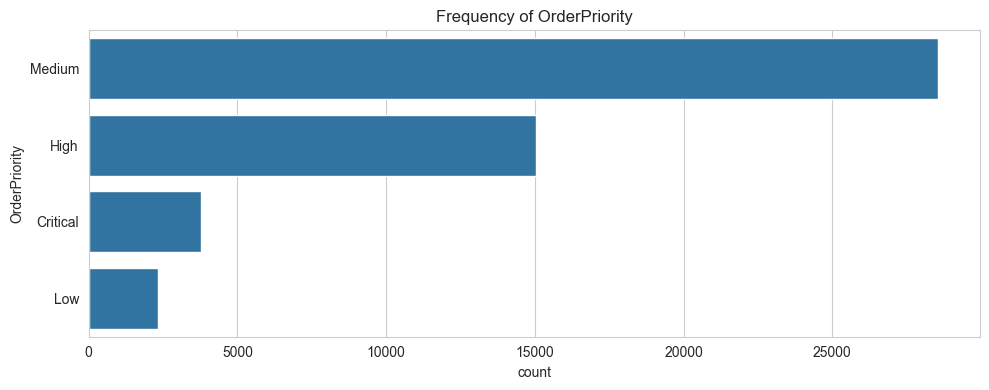

OrderPriority
Medium      57.455204
High        30.275820
Critical     7.588081
Low          4.680894
Name: proportion, dtype: float64


In [14]:
categorical_cols = ['Category', 'Sub-Category', 'Segment', 'Region', 'Market', 'ShipMode', 'OrderPriority']
eda.plot_categorical_frequencies(categorical_cols)

## Bivariate Analysis: Numerical vs. Numerical

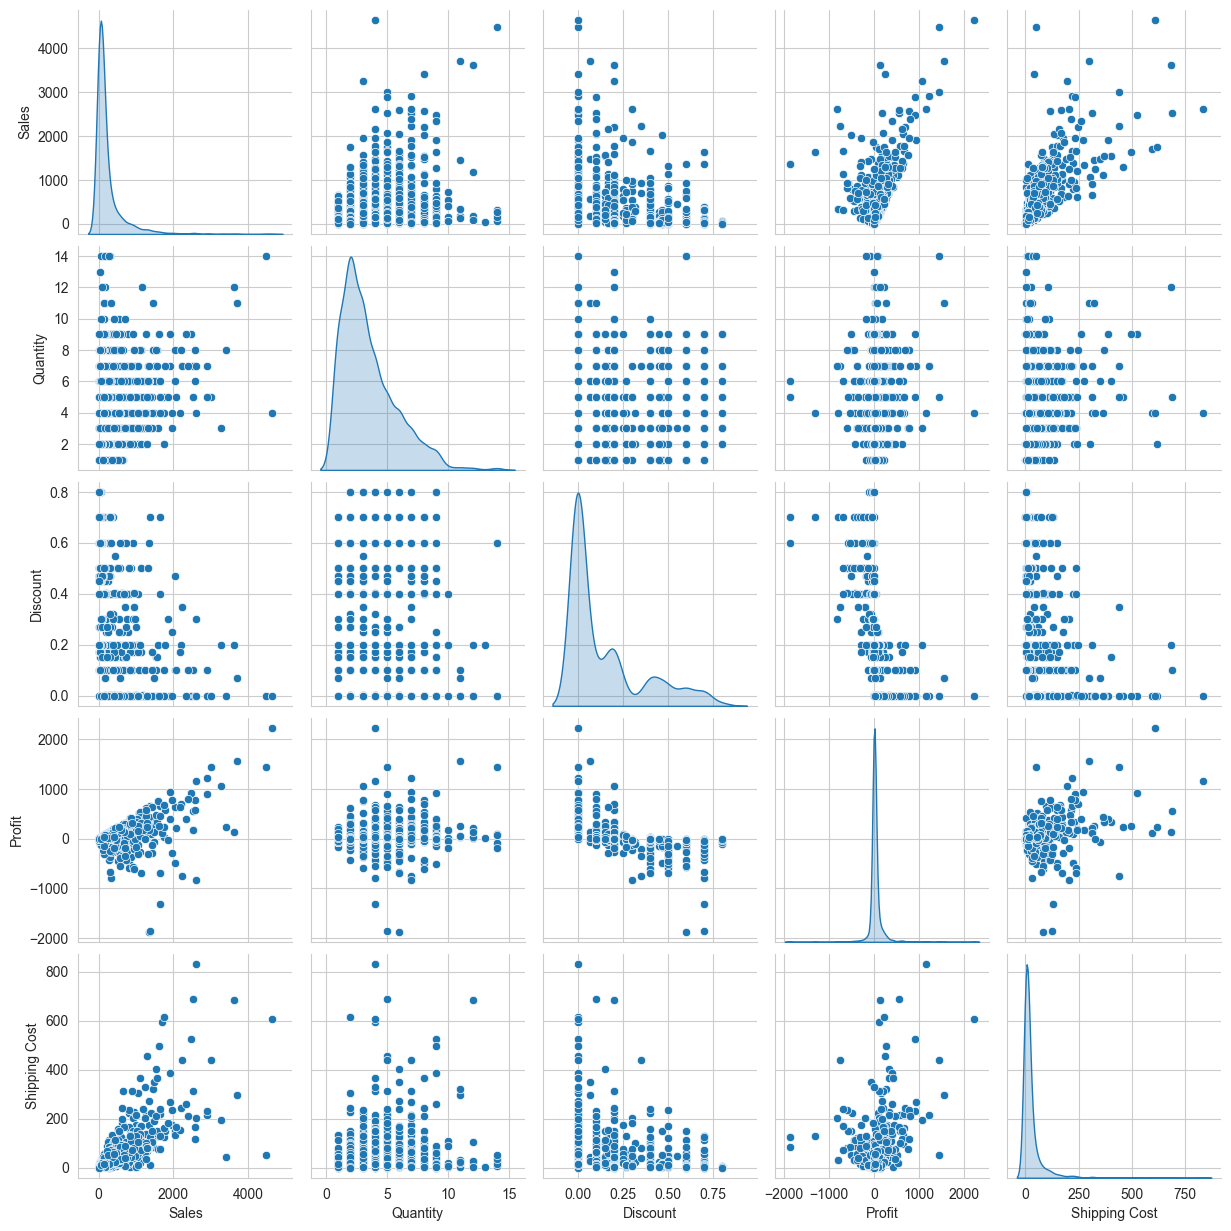

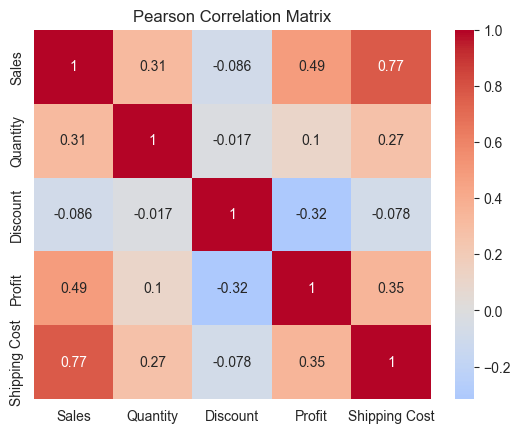

In [15]:
eda.plot_numeric_pairwise(numeric_cols)

## Bivariate Analysis: Numerical vs. Categorical (Comparing means across groups)


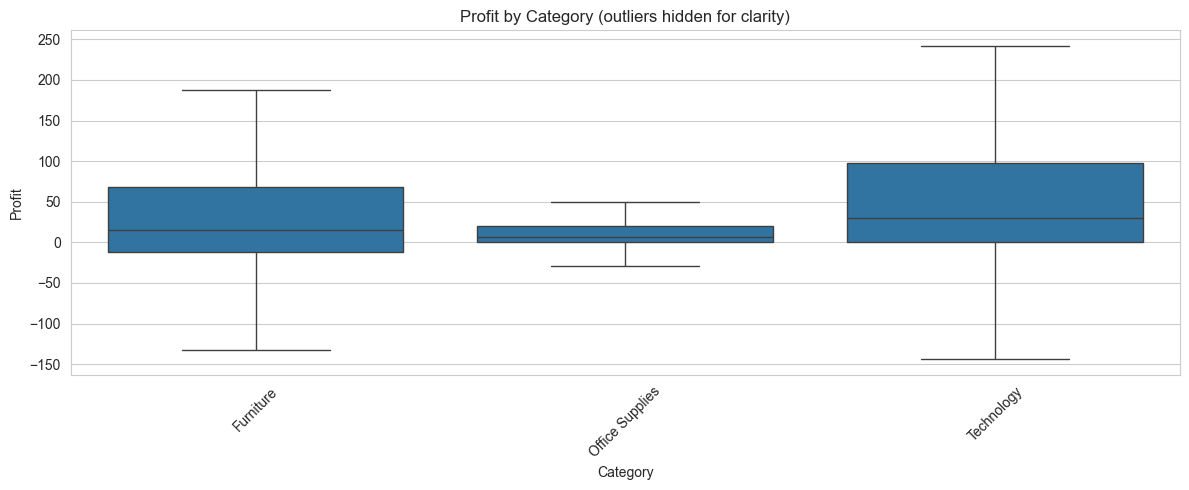

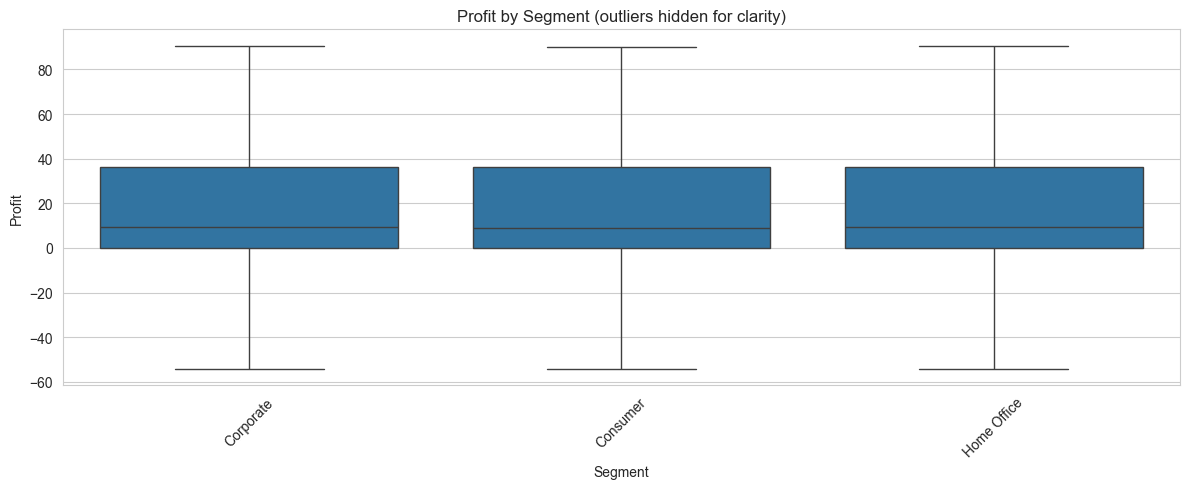

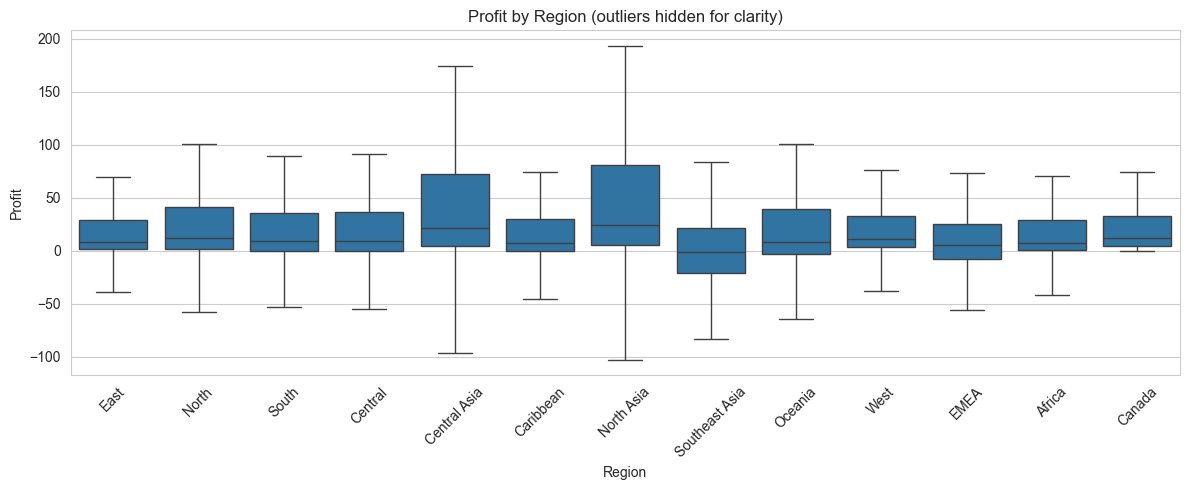

In [16]:
eda.plot_numeric_by_categories(['Category', 'Segment', 'Region'], value_col='Profit')

## Bivariate Analysis: Categorical vs. Categorical

Region           Africa  Canada  Caribbean  Central  Central Asia  EMEA  East  \
Category                                                                        
Furniture           615      40        371     1905           478   730   599   
Office Supplies    2949     273        968     6400          1111  3182  1700   
Technology          889      63        339     1944           459   923   533   

Region           North  North Asia  Oceania  South  Southeast Asia  West  
Category                                                                  
Furniture          906         522      742   1298             687   702  
Office Supplies   2793        1332     1961   3952            1773  1893  
Technology         869         484      784   1240             669   592  


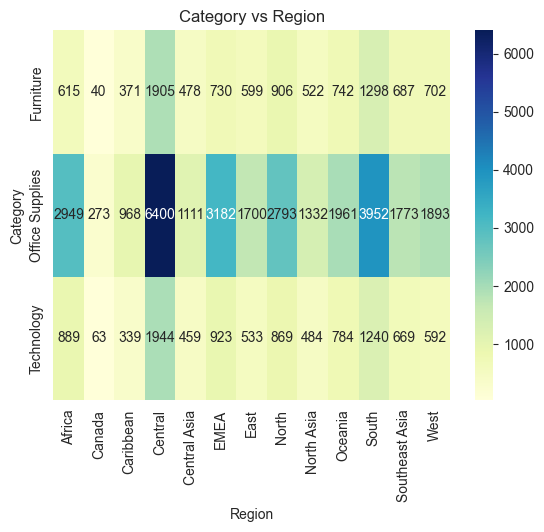

In [17]:
eda.plot_categorical_crosstab_heatmap('Category', 'Region')

## Time Series

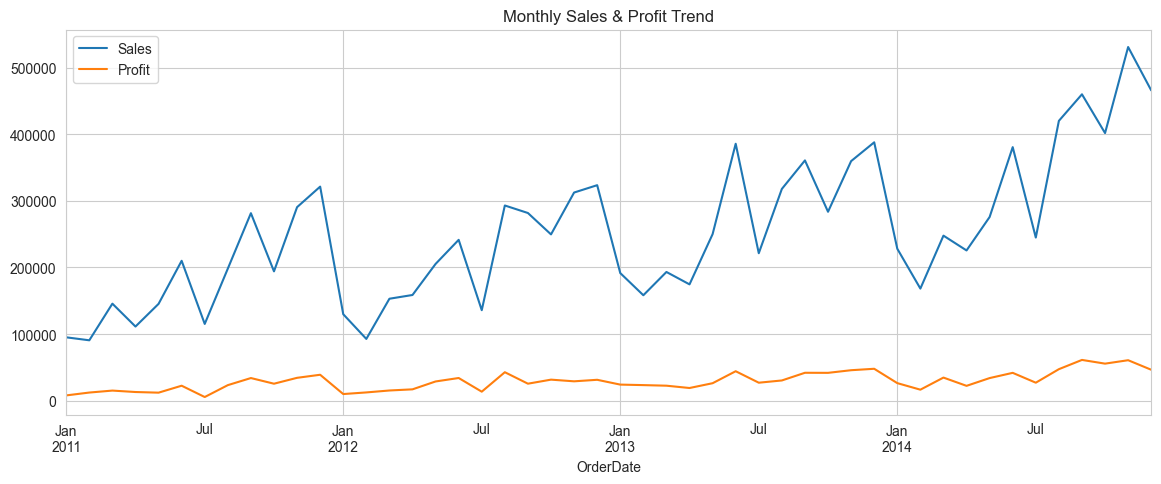

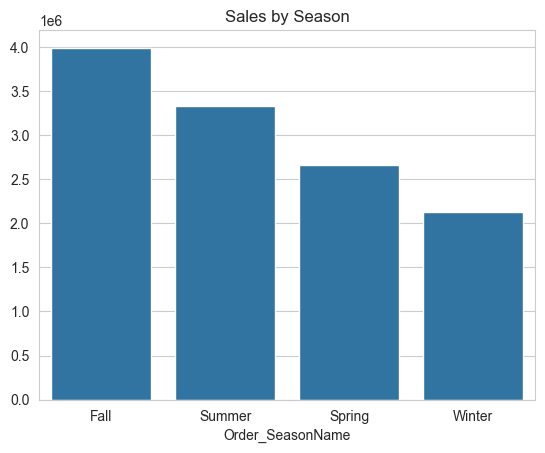

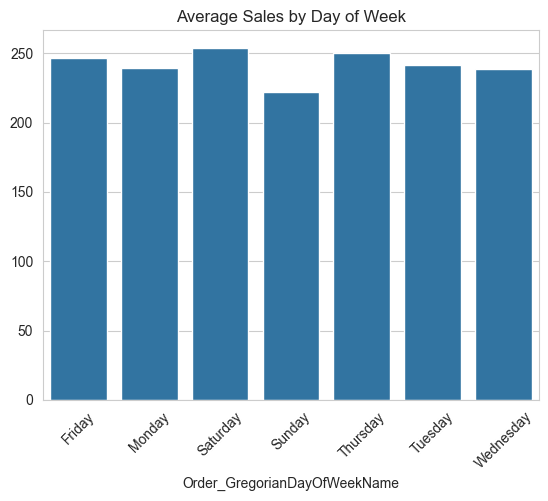

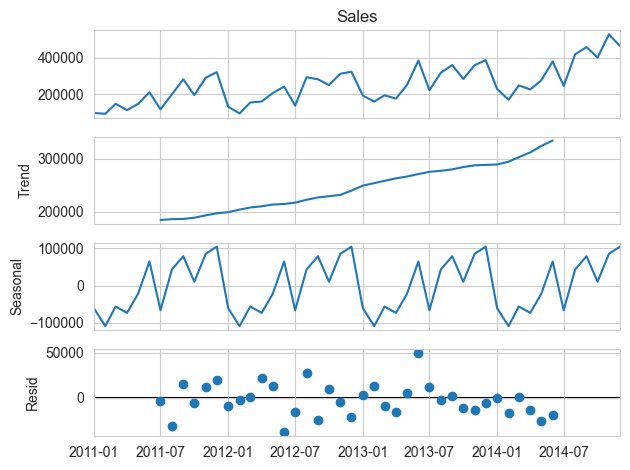

In [18]:
eda.plot_time_series_overview()

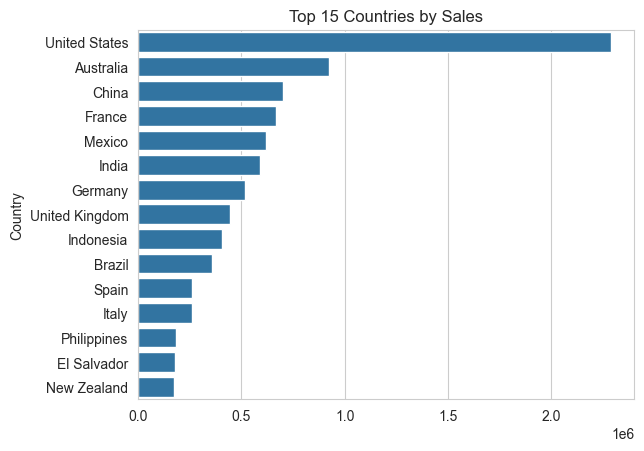

         total_sales  avg_profit  order_count
Market                                       
APAC    3.585744e+06   39.629162         5437
EU      2.482800e+06   34.331468         4593
US      2.287823e+06   28.831310         4990
LATAM   2.150875e+06   21.955399         5120
EMEA    7.754550e+05   10.582015         2462
Africa  7.631486e+05   20.432905         2230
Canada  6.570411e+04   46.947926          201


,total_sales,avg_profit,order_count
Market,,,
APAC,3.585744e+06,39.629162,5437
EU,2.482800e+06,34.331468,4593
US,2.287823e+06,28.831310,4990
LATAM,2.150875e+06,21.955399,5120
EMEA,7.754550e+05,10.582015,2462
Africa,7.631486e+05,20.432905,2230
Canada,6.570411e+04,46.947926,201


In [19]:
eda.plot_top_countries_and_market_summary()

In [20]:
eda.analyze_outliers(numeric_cols)

Sales: 5466 outliers (11.0%)
Quantity: 847 outliers (1.7%)
Discount: 3981 outliers (8.0%)
Profit: 9448 outliers (19.0%)
Shipping Cost: 5744 outliers (11.6%)
              Order ID                                        ProductName  \
38667   CA-2011-145317  Cisco TelePresence System EX90 Videoconferenci...   
9238    CA-2013-118689              Canon imageCLASS 2200 Advanced Copier   
47664   CA-2014-140151              Canon imageCLASS 2200 Advanced Copier   
27082   CA-2014-127180              Canon imageCLASS 2200 Advanced Copier   
6696    CA-2014-166709              Canon imageCLASS 2200 Advanced Copier   
11079   CA-2013-117121   GBC Ibimaster 500 Manual ProClick Binding System   
9175    CA-2011-116904               Ibico EPK-21 Electric Binding System   
10398   US-2013-107440   3D Systems Cube Printer, 2nd Generation, Magenta   
17007   CA-2013-158841  HP Designjet T520 Inkjet Large Format Printer ...   
42753   CA-2013-143714              Canon imageCLASS 2200 Advanced Copier

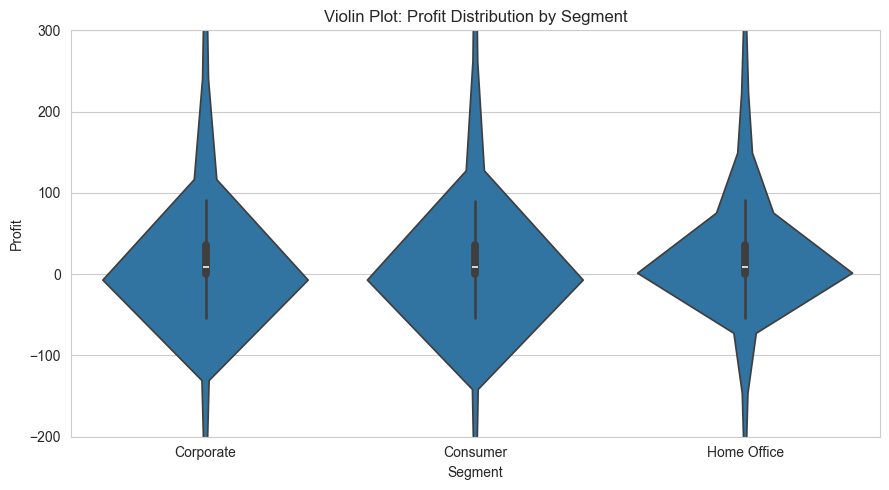

In [21]:
eda.plot_violin_profit_by_segment()

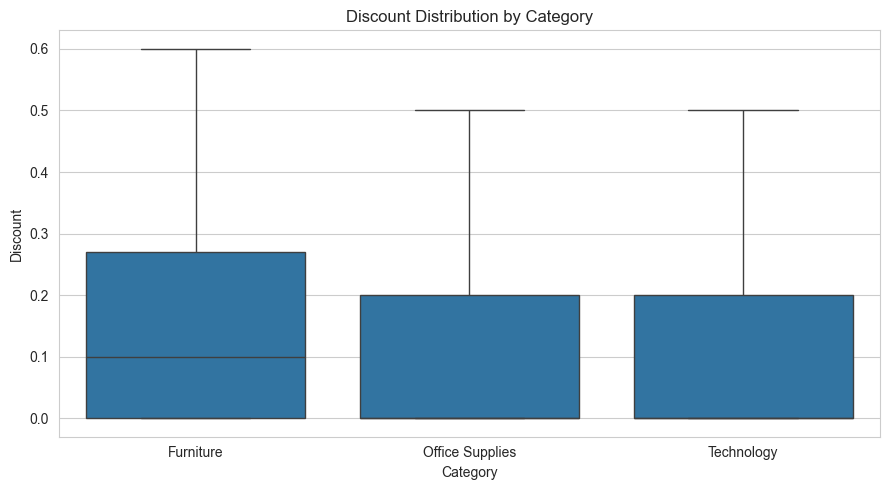

In [22]:
eda.plot_discount_by_category()

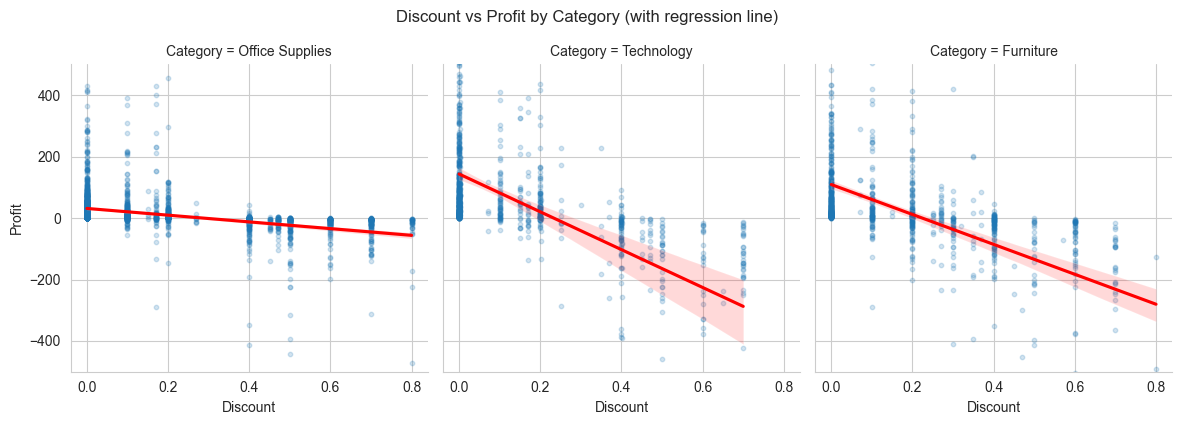

In [23]:
eda.plot_lmplot_discount_profit_by_category()

OrderPriority   Critical  High   Low  Medium
ShipMode                                    
First Class         1671  3287     0    2274
Same Day             708  1247     0     665
Second Class        1390  3881     0    4701
Standard Class         0  6623  2325   20898


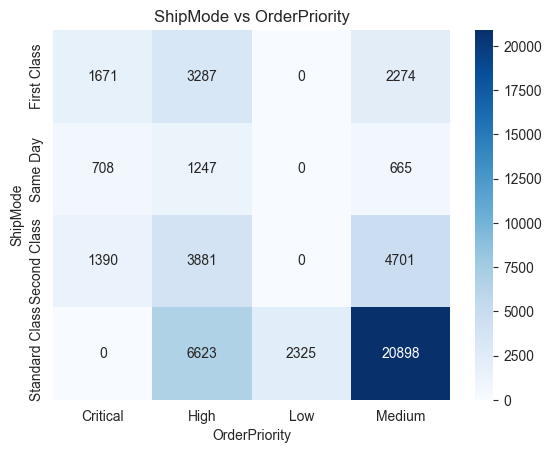

In [24]:
eda.plot_shipmode_priority_heatmap()

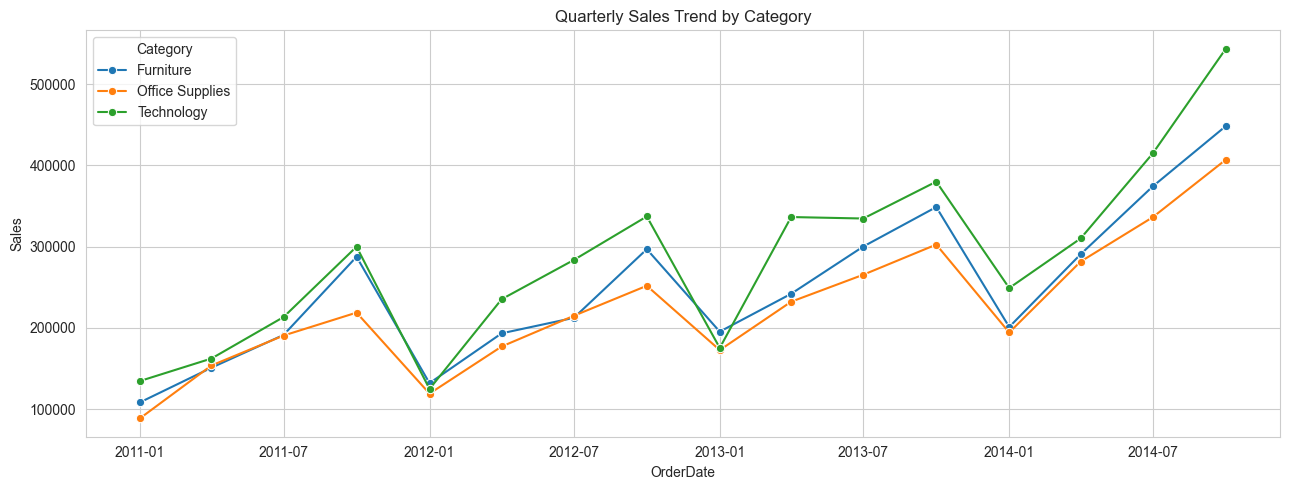

In [25]:
eda.plot_quarterly_trend_by_category()

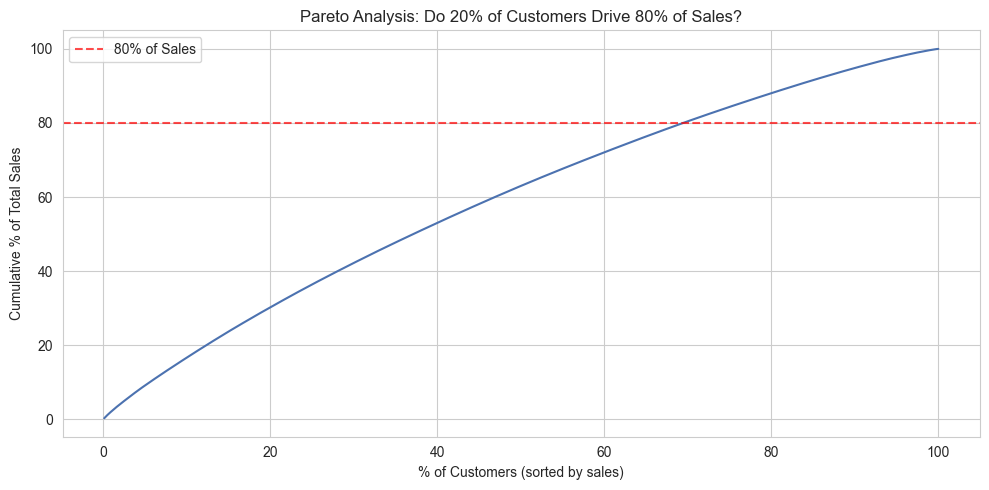

The percentage of customers who account for 80% of sales: 69.3%


np.float64(69.30817610062893)

In [26]:
eda.plot_pareto_customers()

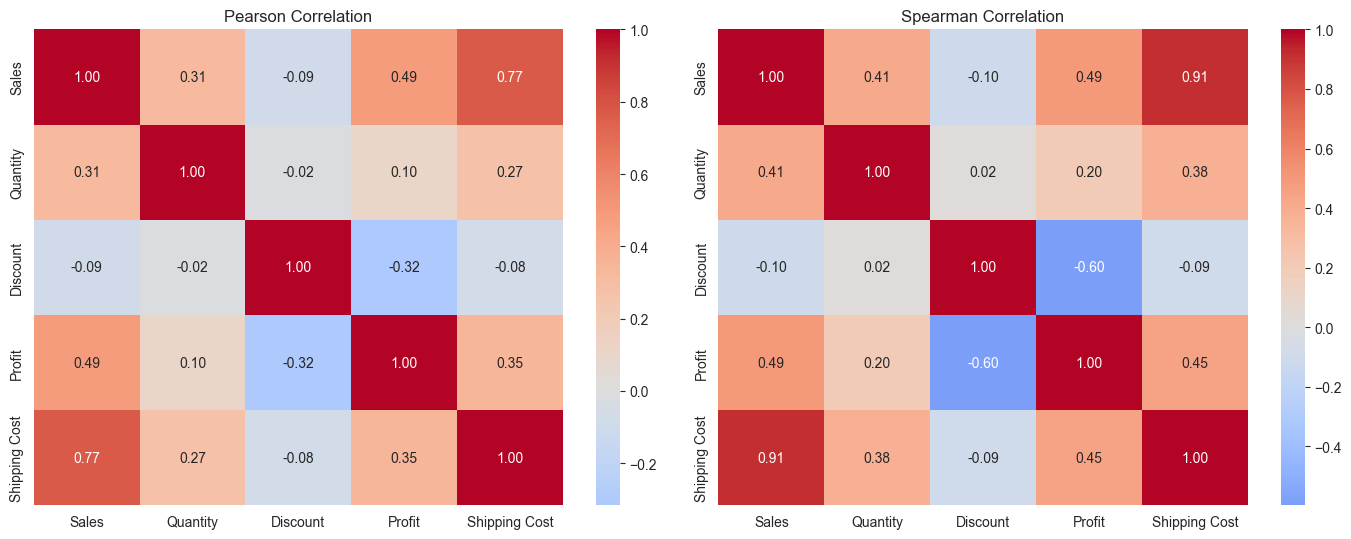

In [27]:
eda.plot_pearson_vs_spearman(numeric_cols)

### Advanced EDA — deeper static views

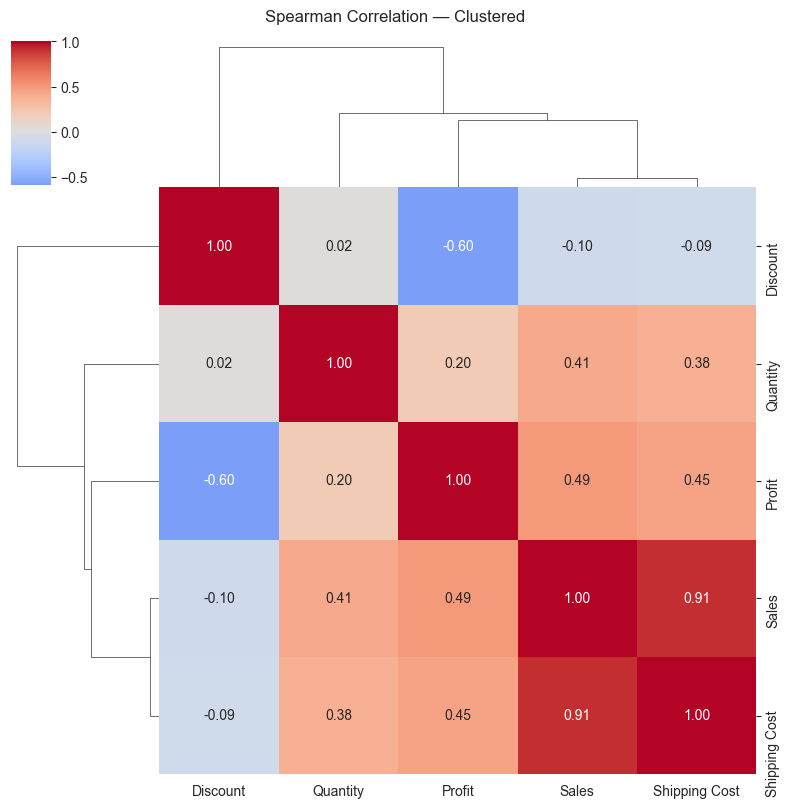

In [28]:
eda.plot_correlation_clustermap(numeric_cols, method='spearman')

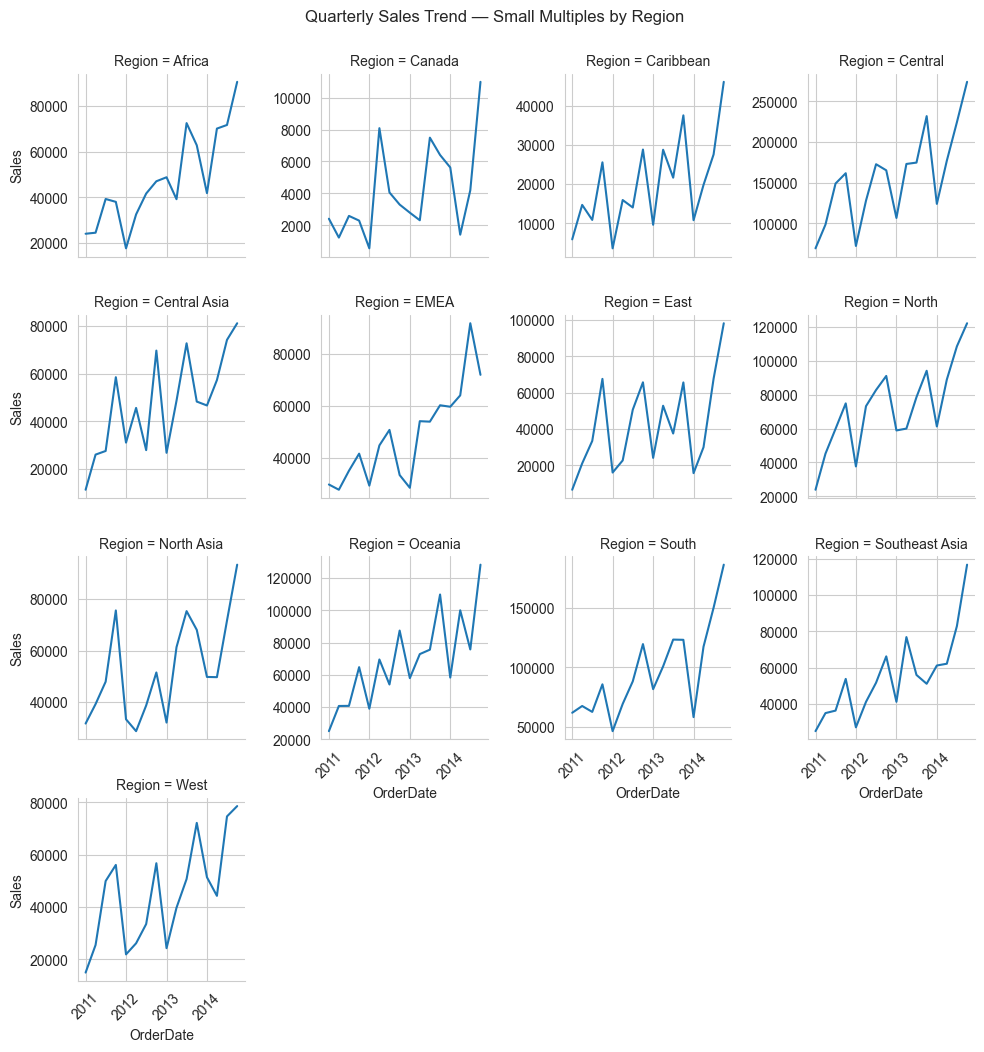

In [29]:
eda.plot_small_multiples_trend_by_region(value_col='Sales')

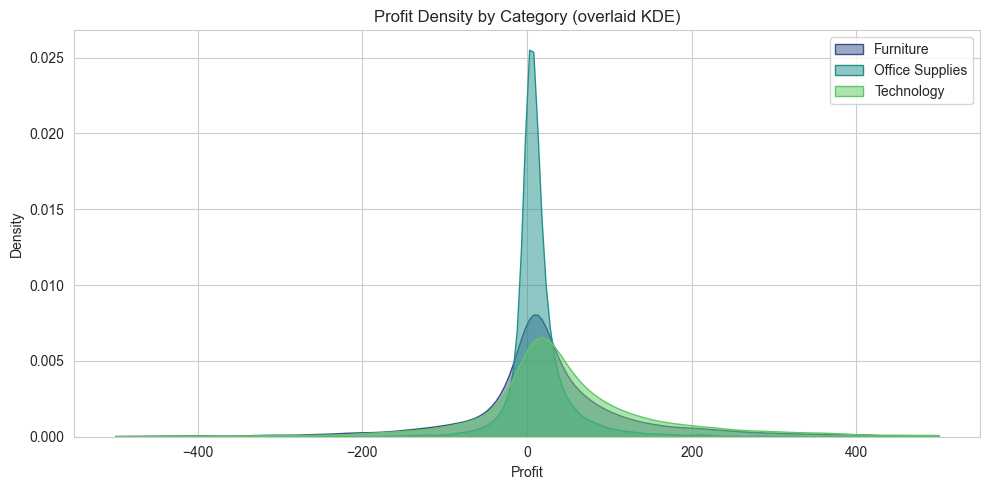

In [30]:
eda.plot_ridge_profit_by_category()

### Interactive EDA (Plotly)

In [31]:
iviz = InteractiveEDA(df)

In [32]:
iviz.scatter_sales_vs_profit()

In [33]:
iviz.treemap_category_subcategory()

In [34]:
iviz.sunburst_geography()

In [35]:
iviz.monthly_trend_with_rangeslider(value_col='Sales')

In [36]:
iviz.choropleth_sales_by_country()

In [37]:
iviz.parallel_categories_returns()

## Statistical Hypothesis Testing

In [38]:
tester = HypothesisTester(df)

### Hypothesis 1: Does Discount Affect the Quantity Sold?

**Research Question:** Does applying a discount to an item lead to a noticeable change in the quantity purchased?

**Groups:** Discounted items (`Discount > 0`) vs. Non-discounted items (`Discount = 0`)

---

**Step 1 — Normality Test (Shapiro-Wilk)**
- H0: The distribution of `Quantity` in the group is normal
- H1: The distribution of `Quantity` in the group is not normal

Result: p ≈ 0.000000 for both groups → **H0 rejected** → data is not normally distributed.

---

**Step 2 — Homogeneity of Variance (Levene's Test)**
- H0: The variances of `Quantity` are equal across the two groups
- H1: The variances of `Quantity` are not equal across the two groups

Result: statistic = 5.85, p = 0.0156 → **H0 rejected** → variances are unequal.

---

**Step 3 — Main Test (Mann-Whitney U, since data is non-normal)**
- H0: The distribution of `Quantity` is the same in both groups (no difference between discounted and non-discounted items)
- H1: The distribution of `Quantity` differs between the two groups

Result: U-statistic, p ≈ 0.000000 → **H0 rejected** → statistically significant difference.

(For reference, Independent t-test with unequal variances: t = 8.41, p ≈ 0.000000 — same conclusion)

---

**Effect Size (Cohen's d)**
Mean difference = 0.173 units, Cohen's d = 0.076 → **negligible effect** (below the 0.2 threshold)

---

**Conclusion:** Although the difference is statistically significant (p < 0.05) due to the large sample size (n=49,670), the practical effect size is negligible (Cohen's d = 0.076). Discounted items are purchased on average only 0.17 units more than non-discounted items — not a meaningful behavioral difference. **The claim that "discounts substantially increase purchase quantity" is not supported.**

has_discount
No discount    28103
Discounted     21567
Name: count, dtype: int64

                count      mean       std  min  25%  50%  75%   max
has_discount                                                       
Discounted    21567.0  3.568507  2.258748  1.0  2.0  3.0  5.0  14.0
No discount   28103.0  3.395794  2.284344  1.0  2.0  3.0  5.0  14.0



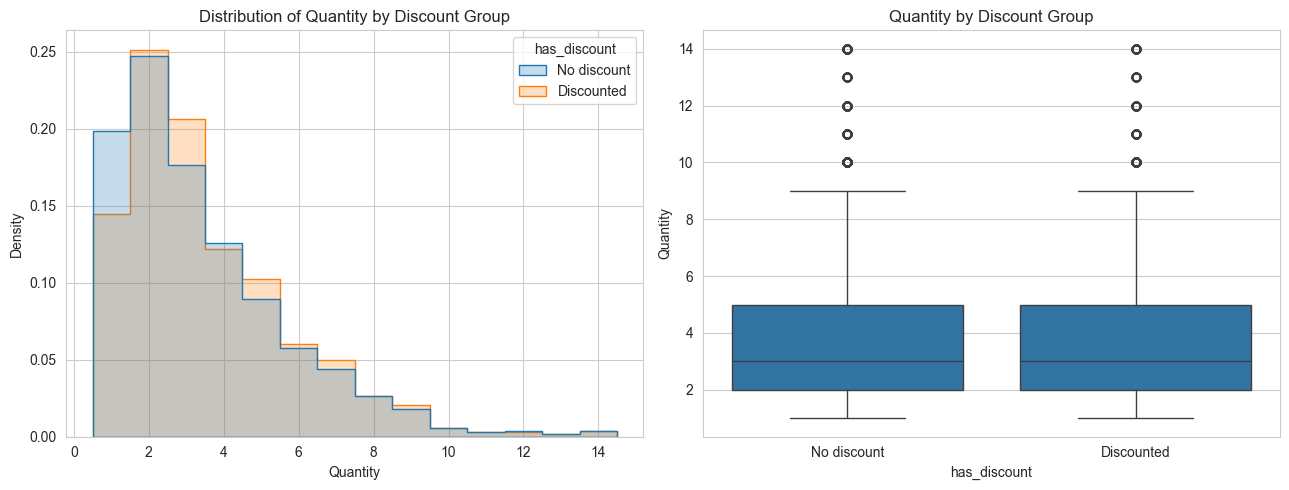

Shapiro-Wilk [Discounted]: p=0.000000 → not normal
Shapiro-Wilk [No discount]: p=0.000000 → not normal

Levene's Test: statistic=5.8522, p=0.015561 → Variances are not equal

Independent t-test: t=8.4051, p=0.000000
Mann-Whitney U: U=320990669.50, p=0.000000  ← Recommended test

Mean Difference: 0.1727
Cohen's d: 0.0760  (negligible)


{'p_ttest': np.float64(4.393281673026962e-17),
 'p_mwu': np.float64(1.236617946793379e-30),
 'cohens_d': np.float64(0.07603220746112231)}

In [39]:
tester.run_hypothesis_discount_vs_quantity()

### Hypothesis 2: Does Profit Differ Across Product Categories?

**Research Question:** Is there a statistically significant difference in average `Profit` among the three product categories (Furniture, Office Supplies, Technology)?

**Groups:** Furniture, Office Supplies, Technology (mean Profit: 28.23, 16.46, 65.46 respectively)

---

**Step 1 — Normality Test (Shapiro-Wilk, per group)**
- H0: `Profit` is normally distributed within each category
- H1: `Profit` is not normally distributed within each category

Result: p ≈ 0.000000 for all three categories → **H0 rejected** → non-normal in all groups.

---

**Step 2 — Homogeneity of Variance (Levene's Test)**
- H0: The variance of `Profit` is equal across all three categories
- H1: At least one category has a different variance

Result: statistic = 1397.54, p ≈ 0.000000 → **H0 rejected** → variances are unequal.

---

**Step 3 — Main Test (Kruskal-Wallis, since data is non-normal with unequal variances)**
- H0: The distribution of `Profit` is the same across all three categories (no difference in central tendency)
- H1: At least one category has a different distribution of `Profit`

Result: H-statistic = 1752.72, p ≈ 0.000000 → **H0 rejected**.

(For reference, One-way ANOVA: F = 302.34, p ≈ 0.000000 — same conclusion)

---

**Step 4 — Post-hoc Pairwise Comparison (Mann-Whitney U with Bonferroni correction, α = 0.0167)**
- H0 (for each pair): The two categories have the same `Profit` distribution
- H1 (for each pair): The two categories have different `Profit` distributions

| Comparison | p-value | Result |
|---|---|---|
| Furniture vs Office Supplies | p ≈ 0.000000 | H0 rejected — significant |
| Furniture vs Technology | p ≈ 0.000000 | H0 rejected — significant |
| Office Supplies vs Technology | p ≈ 0.000000 | H0 rejected — significant |

---

**Conclusion:** All pairwise comparisons are statistically significant, and the magnitude of the differences is substantial (Technology's mean profit is roughly 4x that of Office Supplies). **Technology is a genuinely and meaningfully more profitable category** — this is both statistically and practically significant.

                   count       mean         std          min        25%  \
Category                                                                  
Furniture         9595.0  28.232305  204.021184 -2750.280029 -12.098000   
Office Supplies  30287.0  16.464212  107.285770 -3701.889893   0.450000   
Technology        9788.0  65.458029  269.444431 -6599.979980   0.706725   

                     50%        75%          max  
Category                                          
Furniture        15.3000  68.124599  2316.510010  
Office Supplies   6.4800  20.340000  4946.370117  
Technology       29.5401  97.199997  8399.980469  



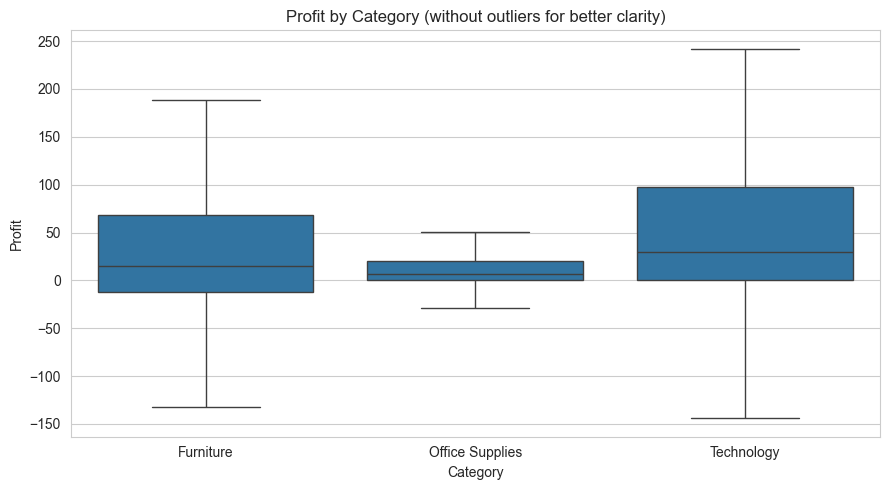

Shapiro [Furniture]: p=0.000000 → Not normal
Shapiro [Office Supplies]: p=0.000000 → Not normal
Shapiro [Technology]: p=0.000000 → Not normal

Levene: statistic=1397.5369, p=0.000000

Kruskal-Wallis: stat=1752.7204, p=0.000000
One-way ANOVA (for comparison): F=302.3449, p=0.000000

Post-hoc pairwise (Mann-Whitney U + Bonferroni correction):
  Furniture vs Office Supplies: p=0.000000 (threshold=0.01667) → Significant | mean1=28.23, mean2=16.46
  Furniture vs Technology: p=0.000000 (threshold=0.01667) → Significant | mean1=28.23, mean2=65.46
  Office Supplies vs Technology: p=0.000000 (threshold=0.01667) → Significant | mean1=16.46, mean2=65.46


{'p_kruskal': np.float64(0.0), 'p_anova': np.float64(3.0631774478815863e-131)}

In [40]:
tester.run_hypothesis_profit_by_category()

### Hypothesis 3: Does Return Rate Differ Across Product Categories?

**Research Question:** Is there an association between product `Category` and whether an item is returned (`IsReturned`)?

**Variables:** Two categorical variables — `Category` (3 levels) and `IsReturned` (Yes/No)

---

**Pre-check — Expected Cell Frequency**
Requirement: all expected cell counts in the contingency table should be ≥ 5 for the Chi-Square test to be valid.

Result: minimum expected count = [value from your run] → assumption satisfied.

---

**Main Test (Chi-Square Test of Independence)**
- H0: `Category` and `IsReturned` are independent (no relationship between them)
- H1: `Category` and `IsReturned` are not independent (there is a relationship)

Result: x^2 = 9.4753, df = 2, p = 0.00876 → **H0 rejected** → statistically significant association.

Return rates by category: Office Supplies 5.75%, Technology 6.24%, Furniture 6.55%

---

**Effect Size (Cramér's V)**
Cramér's V = [value from your run] → **negligible to small association**

---

**Conclusion:** While the Chi-Square test indicates a statistically significant relationship (p < 0.05) — again a consequence of the large sample size — the actual difference in return rates (5.75% to 6.55%, a spread of only 0.8 percentage points) is very small. **The practical significance of this relationship is minimal.**

IsReturned          No   Yes
Category                    
Furniture         8967   628
Office Supplies  28546  1741
Technology        9177   611



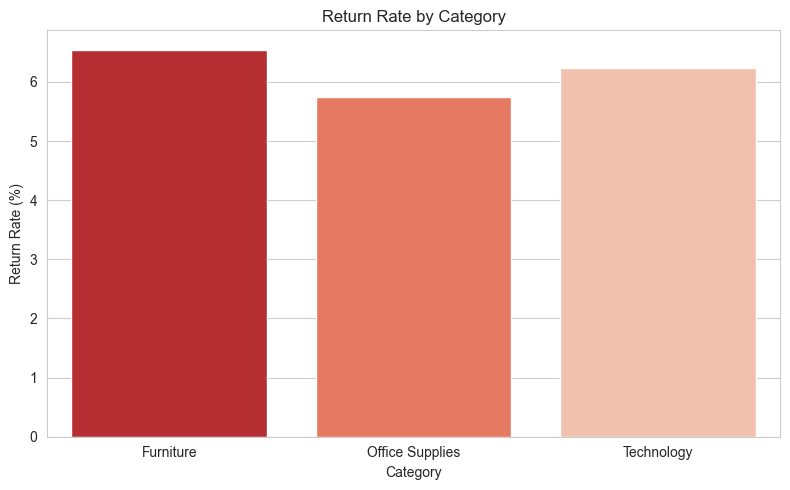

Return Rate by Category (%):
Category
Furniture          6.55
Office Supplies    5.75
Technology         6.24
dtype: float64

Minimum expected count in contingency table: 575.7  (Acceptable (>=5))

Chi-Square: χ²=9.4753, p-value=0.008759, dof=2
Cramér's V: 0.0138  (negligible)


{'chi2': np.float64(9.475254304052706),
 'p': np.float64(0.008759406284906197),
 'cramers_v': np.float64(0.013811738823720311)}

In [41]:
tester.run_hypothesis_return_by_category()

### Hypothesis 4: Is There a Relationship Between Discount and Profit?

**Research Question:** Does increasing the discount level correlate with a decrease in profit? (This directly tests whether stores actually profit more by offering discounts.)

**Variables:** `Discount` (continuous, 0 to 0.85) and `Profit` (continuous, can be negative)

---

**Step 1 — Normality Test (Shapiro-Wilk)**
- H0: The variable is normally distributed
- H1: The variable is not normally distributed

Result: p ≈ 0.000000 for both `Discount` and `Profit` → **H0 rejected** for both → non-normal, favoring Spearman over Pearson.

---

**Step 2 — Correlation Test**

*Pearson (linear relationship, assumes normality):*
- H0: ρ = 0 (no linear correlation between Discount and Profit)
- H1: ρ ≠ 0 (a linear correlation exists)

Result: r = -0.316, p ≈ 0.000000 → **H0 rejected**.

*Spearman (monotonic relationship, robust to non-normality — more appropriate here):*
- H0: There is no monotonic relationship between Discount and Profit
- H1: There is a monotonic relationship between Discount and Profit

Result: ρ (rho) = -0.598, p ≈ 0.000000 → **H0 rejected**.

---

**Conclusion:** Both tests reject the null hypothesis, confirming a **negative and moderately strong relationship** between discount level and profit (Spearman ρ = -0.598 is the more reliable estimate given the skewed distributions). **As discounts increase, profit decreases substantially** — directly contradicting the popular belief that discounting leads to higher profits.

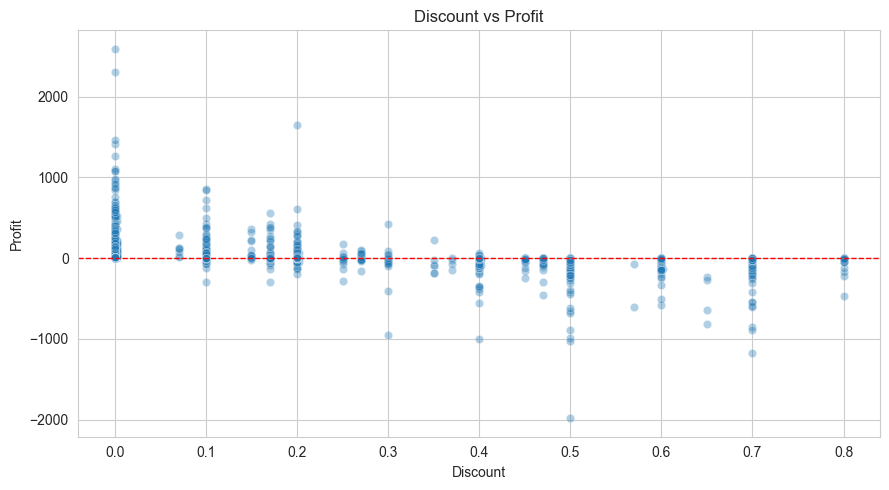

Shapiro [Discount]: p=0.000000 → Not normal
Shapiro [Profit]: p=0.000000 → Not normal

Pearson r=-0.3162, p-value=0.000000
Spearman rho=-0.5982, p-value=0.000000  ← Recommended test (more reliable due to non-normality)


{'pearson_r': np.float64(-0.31620110166620863),
 'spearman_rho': np.float64(-0.5981781834244791)}

In [42]:
tester.run_hypothesis_discount_vs_profit()

### Conclusion

The popular claim — *"stores use discounts to trick people into buying more, ultimately making more money"* — is **not supported by the data**:

1. **Quantity effect:** Discounts have a statistically significant but practically negligible effect on quantity purchased (see Cohen's d above).
2. **Profit effect:** Discounts show a moderately strong **negative** correlation with profit (see Spearman ρ above), directly contradicting the "more profit" claim.

This distinction between **statistical significance** (driven largely by the large sample size) and **practical/effect-size significance** is the central methodological insight of this analysis.

# Multivariate Tests

In [43]:
tester = HypothesisTester(df)

### Multicollinearity Check (VIF)

**Why this matters:** Before combining several numeric variables in a
MANOVA/MANCOVA, we need to make sure they aren't redundant with each
other. Earlier EDA showed Sales and Shipping Cost are correlated at
0.91 (Pearson) — this check tells us whether that's a problem.

- Rule of thumb: VIF < 5 is safe, VIF 5-10 is borderline, VIF > 10 is
  a real multicollinearity problem.

In [ ]:
tester.check_vif(['Sales', 'Profit', 'Discount', 'Shipping Cost'])

         feature       VIF
0          const  1.809471
1          Sales  2.823276
2         Profit  1.458682
3       Discount  1.119872
4  Shipping Cost  2.445216


,feature,VIF
0,const,1.809471
1,Sales,2.823276
2,Profit,1.458682
3,Discount,1.119872
4,Shipping Cost,2.445216


**Result:**

| Feature | VIF |
|---|---|
| Sales | 2.82 |
| Profit | 1.46 |
| Discount | 1.12 |
| Shipping Cost | 2.45 |

All values are well below the 5.0 threshold. Even though Sales and
Shipping Cost are strongly *correlated*, once all four variables are
considered together they don't create a multicollinearity problem —
each still carries distinct information. **It's safe to proceed with
MANOVA/MANCOVA using these variables.**

### Two-Way ANOVA: Category × Segment on Profit

**Research Question:** Does Segment influence Profit on top of Category?
And does the effect of Category on Profit *depend on* which Segment the
customer belongs to (interaction)?

**H0 (Category):** Mean Profit is equal across Category levels
**H1 (Category):** At least one Category differs

**H0 (Segment):** Mean Profit is equal across Segment levels
**H1 (Segment):** At least one Segment differs

**H0 (Interaction):** The effect of Category on Profit does not depend
on Segment (the interaction lines would be parallel)
**H1 (Interaction):** The effect of Category on Profit depends on Segment

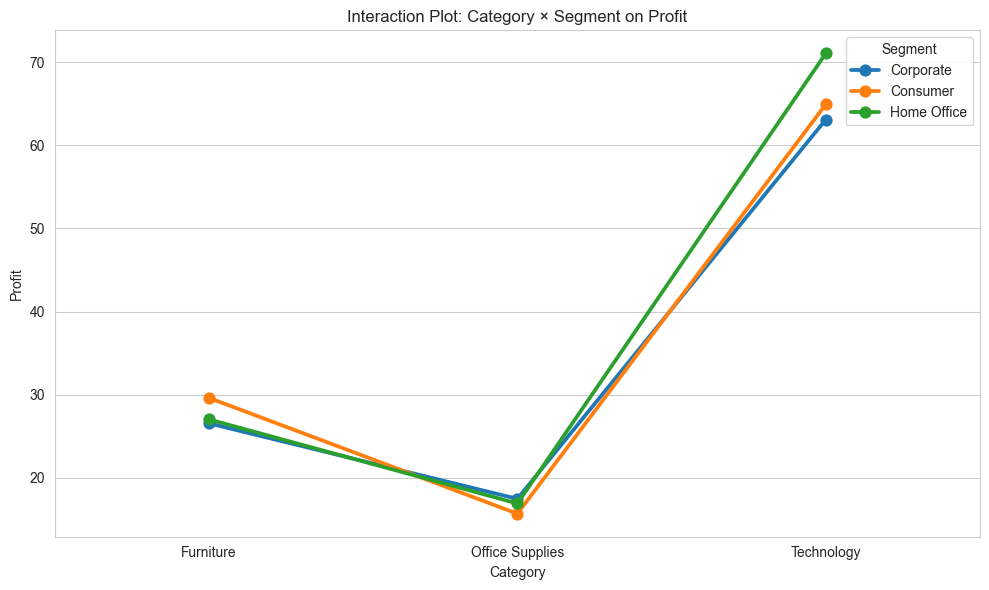

                              sum_sq       df           F         PR(>F)
C(Category)             1.776243e+07      2.0  302.426182  2.827420e-131
C(Segment)              1.449248e+04      2.0    0.246751   7.813358e-01
C(Category):C(Segment)  9.774511e+04      4.0    0.832112   5.044444e-01
Residual                1.458373e+09  49661.0         NaN            NaN


,sum_sq,df,F,PR(>F)
C(Category),1.776243e+07,2.0,302.426182,2.827420e-131
C(Segment),1.449248e+04,2.0,0.246751,7.813358e-01
C(Category):C(Segment),9.774511e+04,4.0,0.832112,5.044444e-01
Residual,1.458373e+09,49661.0,NaN,NaN


In [ ]:
tester.run_twoway_anova('Category', 'Segment', 'Profit')

**Result:**

| Effect | F | p-value | Conclusion |
|---|---|---|---|
| C(Category) | 302.43 | 2.83e-131 | **Significant** — H0 rejected |
| C(Segment) | 0.25 | 0.781 | Not significant — fail to reject H0 |
| C(Category):C(Segment) | 0.83 | 0.504 | Not significant — fail to reject H0 |

**Interpretation:** Category remains an extremely strong driver of
Profit, exactly as the earlier one-way test (Hypothesis 2) showed.
However, **Segment on its own has no significant effect on Profit**,
and — importantly — **there is no significant interaction** between
Category and Segment (p=0.504).

> **Note on the earlier exploratory observation:** raw group means had
> suggested a possible "crossover" pattern (e.g. Home Office looking
> most profitable within Technology, but least profitable within
> Furniture). This formal test shows that pattern is **not
> statistically distinguishable from random noise** once we account
> for the spread within each group — a good reminder that eyeballing
> a small table of means can be misleading, and why we run the formal
> test before drawing conclusions.

**Practical takeaway:** for profitability analysis, Category is the
variable that matters — Segment (Consumer/Corporate/Home Office)
doesn't need to be treated as a separate driver or moderator of Profit.

### MANOVA: Category on (Sales, Profit, Discount)

**Research Question:** Does Category affect the *combined* pattern of
Sales, Profit, and Discount together, rather than testing each one
separately (which would ignore the correlation between them)?

**H0:** The mean vector of (Sales, Profit, Discount) is equal across
Category levels
**H1:** At least one Category has a different mean vector

In [ ]:
tester.run_manova(['Sales', 'Profit', 'Discount'], 'Category')

                    Multivariate linear model
                                                                 
-----------------------------------------------------------------
       Intercept        Value  Num DF   Den DF    F Value  Pr > F
-----------------------------------------------------------------
          Wilks' lambda 0.7641 3.0000 49665.0000 5110.3397 0.0000
         Pillai's trace 0.2359 3.0000 49665.0000 5110.3397 0.0000
 Hotelling-Lawley trace 0.3087 3.0000 49665.0000 5110.3397 0.0000
    Roy's greatest root 0.3087 3.0000 49665.0000 5110.3397 0.0000
-----------------------------------------------------------------
                                                                 
-----------------------------------------------------------------
      C(Category)       Value  Num DF   Den DF    F Value  Pr > F
-----------------------------------------------------------------
          Wilks' lambda 0.8846 6.0000 99330.0000 1047.0836 0.0000
         Pillai's trace 0.1160

**Result (Wilks' Lambda for C(Category)):**

Wilks' λ = 0.8846, F = 1047.08, p ≈ 0.000000

**Interpretation:** H0 is strongly rejected. Category has a highly
significant effect on the *joint* distribution of Sales, Profit, and
Discount — confirming what the univariate tests suggested individually,
but now with the correlation between these three metrics properly
accounted for rather than risking an inflated false-positive rate from
testing them one at a time.

### ANCOVA: Category on Profit, Controlling for Discount

**Research Question:** Is the Profit difference between Categories real,
or is it simply because some categories happen to receive more discount
than others? ANCOVA removes the linear effect of Discount before testing
Category.

**H0:** After controlling for Discount, mean Profit is equal across
Category levels
**H1:** After controlling for Discount, at least one Category differs

In [ ]:
tester.run_ancova('Profit', 'Category', 'Discount')

                   sum_sq       df            F         PR(>F)
C(Category)  1.766061e+07      2.0   334.532446  4.833879e-145
Discount     1.475030e+08      1.0  5588.090031   0.000000e+00
Residual     1.310982e+09  49666.0          NaN            NaN

                            OLS Regression Results                            
Dep. Variable:                 Profit   R-squared:                       0.112
Model:                            OLS   Adj. R-squared:                  0.112
Method:                 Least Squares   F-statistic:                     2087.
Date:                Mon, 31 Aug 2026   Prob (F-statistic):               0.00
Time:                        07:17:23   Log-Likelihood:            -3.2332e+05
No. Observations:               49670   AIC:                         6.466e+05
Df Residuals:                   49666   BIC:                         6.467e+05
Df Model:                           3                                         
Covariance Type:            nonrobus

(                   sum_sq       df            F         PR(>F)
 C(Category)  1.766061e+07      2.0   334.532446  4.833879e-145
 Discount     1.475030e+08      1.0  5588.090031   0.000000e+00
 Residual     1.310982e+09  49666.0          NaN            NaN,
 <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x13a1ce360>)

**Result:**

| Effect | F | p-value |
|---|---|---|
| C(Category) | 334.53 | 4.83e-145 |
| Discount | 5588.09 | ≈ 0.000000 |

R² = 0.112 (the model explains 11.2% of the variance in Profit)

**Regression coefficients** (baseline category = Furniture):
- Office Supplies: **-19.47** vs. Furniture (p<0.001)
- Technology: **+28.75** vs. Furniture (p<0.001)
- Discount: **-257.42** — every 1.0 increase in Discount (i.e. going
  from 0% to 100%) is associated with a $257 drop in Profit, holding
  Category constant. Put differently, each 10-percentage-point increase
  in discount costs roughly **$25.70** in profit on average.

**Interpretation:** H0 is rejected — **the Category effect on Profit
survives even after controlling for Discount.** This confirms the
Category differences found in Hypothesis 2 are not just an artifact of
different discount policies; Technology is genuinely more profitable
per item than Furniture and Office Supplies, independent of how much
discount is applied. At the same time, Discount itself remains an
enormous factor (F=5588, by far the strongest single predictor in this
model).

### MANCOVA: Category on (Sales, Profit), Controlling for Discount

**Research Question:** Combines the previous two tests — does Category
affect the joint (Sales, Profit) vector, after removing the effect of
Discount?

**H0:** After controlling for Discount, the mean vector of (Sales,
Profit) is equal across Category levels
**H1:** After controlling for Discount, at least one Category differs

In [ ]:
tester.run_mancova(['Sales', 'Profit'], 'Category', 'Discount')

                    Multivariate linear model
                                                                 
-----------------------------------------------------------------
       Intercept        Value  Num DF   Den DF    F Value  Pr > F
-----------------------------------------------------------------
          Wilks' lambda 0.8569 2.0000 49665.0000 4147.7648 0.0000
         Pillai's trace 0.1431 2.0000 49665.0000 4147.7648 0.0000
 Hotelling-Lawley trace 0.1670 2.0000 49665.0000 4147.7648 0.0000
    Roy's greatest root 0.1670 2.0000 49665.0000 4147.7648 0.0000
-----------------------------------------------------------------
                                                                 
-----------------------------------------------------------------
      C(Category)       Value  Num DF   Den DF    F Value  Pr > F
-----------------------------------------------------------------
          Wilks' lambda 0.8875 4.0000 99330.0000 1527.1716 0.0000
         Pillai's trace 0.1128

**Result (Wilks' Lambda):**

| Effect | Wilks' λ | F | p-value |
|---|---|---|---|
| C(Category) | 0.8875 | 1527.17 | ≈ 0.000000 |
| Discount | 0.8949 | 2914.94 | ≈ 0.000000 |

**Interpretation:** Both effects remain highly significant. Category
continues to drive the joint (Sales, Profit) pattern even after
Discount is controlled for, and Discount independently affects that
same joint pattern very strongly. This is the most complete confirmation
across all five tests: **Category is a genuine, independent driver of
performance — not an artifact of discounting — while Discount remains
the single most powerful lever affecting profitability.**

## Summary: Multivariate Tests

| Test | Main finding |
|---|---|
| VIF | No multicollinearity concern (all VIF < 3) |
| Two-way ANOVA | Category matters strongly; Segment and the Category×Segment interaction do **not** |
| MANOVA | Category significantly affects the joint (Sales, Profit, Discount) pattern |
| ANCOVA | Category's effect on Profit holds even after controlling for Discount |
| MANCOVA | Confirmed jointly for (Sales, Profit): Category and Discount are both independent, significant drivers |

**Bottom line:** Across every multivariate test, **Category** and
**Discount** consistently emerge as the two dominant drivers of
performance in this dataset, while **Segment does not add meaningful
explanatory power** on its own or in interaction with Category. This
refines the earlier exploratory finding and should guide where the
business focuses its analysis going forward — on product category
strategy and discount policy, rather than customer segment.